# NTU Datathon 2026 — Track 2: Intelligent Financial Fraud Detection

**Goal:** predict whether a transaction is fraudulent (`fraud` = 1) while keeping false alarms on legitimate customers low.

**Evaluation metrics:** PR-AUC, F1 and Recall. Accuracy is meaningless here: only ~1.8% of transactions are fraud, so predicting "never fraud" gives 98% accuracy and 0 recall.

**Pipeline:** 1) Understand the problem → 2) Explore → 3) Clean/preprocess → 4) Feature engineering → 5) Baseline → 6) Train & compare → 7) Evaluate → 8) Save model & predict.

> Run in Google Colab: upload `Track 2 Training Dataset.csv` and `Track 2 Testing Dataset.csv` to the Files panel, then *Runtime → Run all*.

In [1]:
import os, sys, warnings, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (average_precision_score, roc_auc_score, f1_score, recall_score,
                             precision_score, precision_recall_curve, confusion_matrix, make_scorer, fbeta_score)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn.inspection import permutation_importance
warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
print('python', sys.version.split()[0], '| sklearn', sklearn.__version__, '| pandas', pd.__version__, '| numpy', np.__version__)

python 3.13.16 | sklearn 1.6.1 | pandas 2.2.3 | numpy 2.1.3


## 1. Load data

In [2]:
TRAIN_PATH = 'Track 2 Training Dataset.csv'
TEST_PATH  = 'Track 2 Testing Dataset.csv'
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)
TARGET = 'fraud'
print('train', train_df.shape, '| test', test_df.shape)
train_df.head()

train (20000, 12) | test (12000, 11)


,id,transaction_amount,transaction_hour,merchant_category,country,transaction_channel,transactions_last_24h,spend_last_24h,account_age,new_device,transactions_last_1h,fraud
0,FR016993,55.03,16,retail,SG,ecommerce,27.0,1791.34,1192.0,0.0,5.0,0
1,FR002433,20.75,1,gaming,SG,mobile_app,3.0,217.96,3073.0,0.0,0.0,0
2,FR009253,21.51,9,entertainment,SG,mobile_app,3.0,62.71,985.0,0.0,0.0,0
3,FR004881,813.98,16,utilities,GB,mobile_app,2.0,110.48,653.0,0.0,1.0,0
4,FR014830,13.54,20,food_delivery,SG,card_present,4.0,114.98,79.0,0.0,0.0,0


## 2. Exploratory data analysis

In [3]:
print(train_df.dtypes, '\n')
print('Fraud rate: %.2f%%  (%d frauds out of %d)' % (100*train_df[TARGET].mean(), train_df[TARGET].sum(), len(train_df)))
pd.DataFrame({'train_missing': train_df.isna().sum(), 'test_missing': test_df.isna().sum()})

id                        object
transaction_amount       float64
transaction_hour           int64
merchant_category         object
country                   object
transaction_channel       object
transactions_last_24h    float64
spend_last_24h           float64
account_age              float64
new_device               float64
transactions_last_1h     float64
fraud                      int64
dtype: object 

Fraud rate: 1.76%  (353 frauds out of 20000)


,train_missing,test_missing
account_age,137,264.0
country,107,268.0
fraud,0,NaN
id,0,0.0
merchant_category,113,259.0
new_device,124,293.0
spend_last_24h,132,267.0
transaction_amount,0,0.0
transaction_channel,123,284.0
transaction_hour,0,0.0


**Observations:** strong class imbalance (~1.8% fraud) → we optimise PR-AUC / F1, use stratified CV and class weighting. Every feature except `id`, amount and hour has ~0.5–1% missing values in both train and test → the model must handle NaNs robustly. `id` is a unique identifier and carries no signal, so it is dropped.

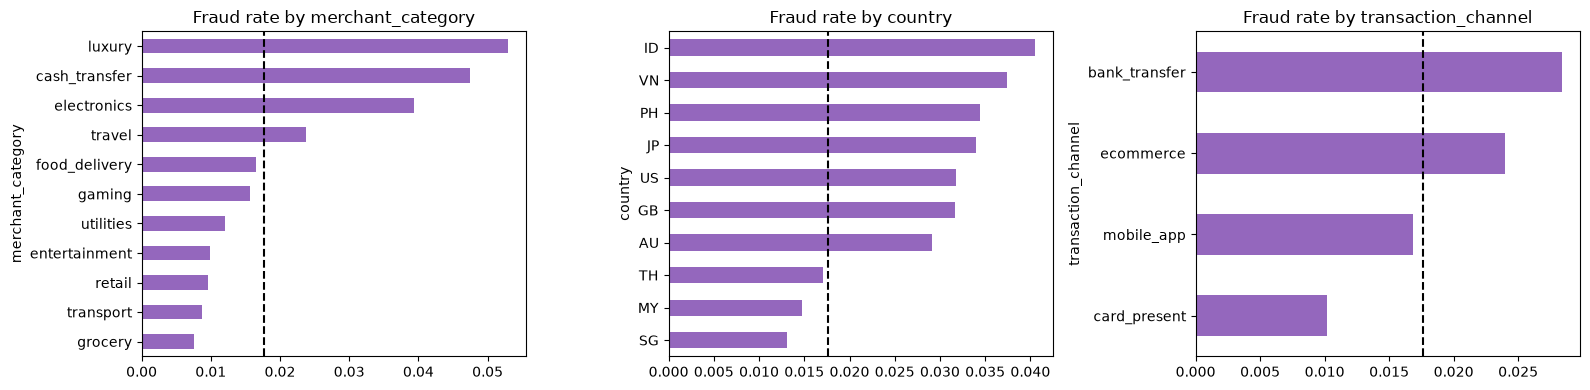

In [4]:
CAT = ['merchant_category', 'country', 'transaction_channel']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axes, CAT):
    r = train_df.groupby(c)[TARGET].mean().sort_values()
    r.plot.barh(ax=ax, color='tab:purple'); ax.set_title(f'Fraud rate by {c}'); ax.axvline(train_df[TARGET].mean(), ls='--', c='k')
plt.tight_layout(); plt.show()

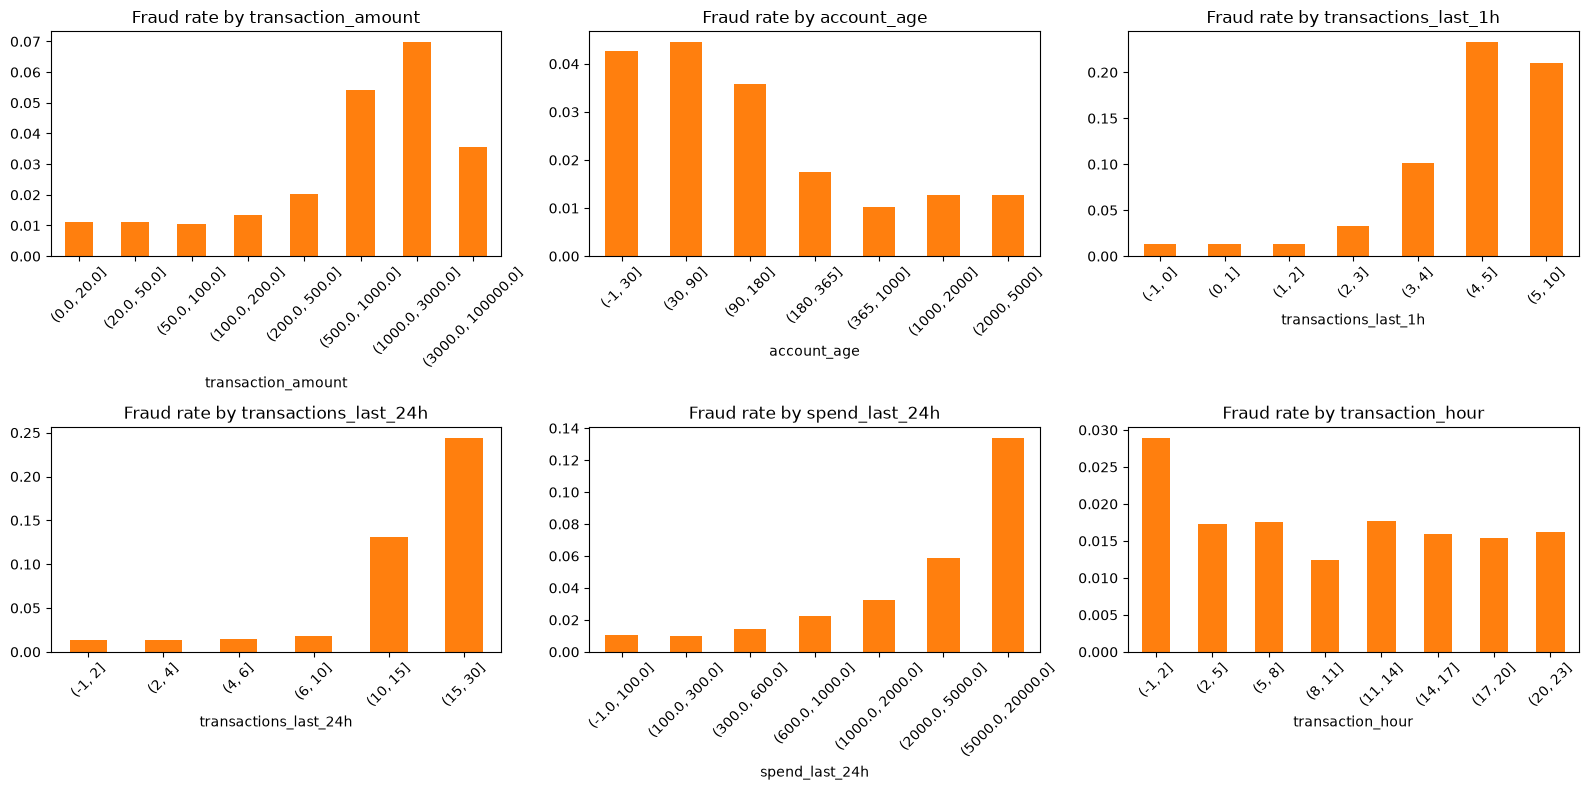

transactions_last_1h  False  True 
new_device                        
0.0                   0.011  0.065
1.0                   0.049  0.375


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
bins = {'transaction_amount':[0,20,50,100,200,500,1000,3000,1e5], 'account_age':[-1,30,90,180,365,1000,2000,5000],
        'transactions_last_1h':[-1,0,1,2,3,4,5,10], 'transactions_last_24h':[-1,2,4,6,10,15,30],
        'spend_last_24h':[-1,100,300,600,1000,2000,5000,2e4], 'transaction_hour':list(range(-1,24,3))}
for ax, (c, b) in zip(axes.ravel(), bins.items()):
    train_df.groupby(pd.cut(train_df[c], b))[TARGET].mean().plot.bar(ax=ax, color='tab:orange')
    ax.set_title(f'Fraud rate by {c}'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()
print(pd.crosstab(train_df.new_device, train_df.transactions_last_1h >= 4, values=train_df[TARGET], aggfunc='mean').round(3))

**Key EDA insights**
- **Amount:** fraud rate is ~1% below 200 and jumps to 5–7% for 500–3000.
- **Account age:** accounts younger than 6 months have ~3× the fraud rate.
- **Velocity:** ≥4 transactions in the last hour → fraud rate 10–30%.
- **New device:** 7.5% vs 1.2%. Combined with a burst of transactions it reaches **~37%** → interactions matter, which favours tree models.
- **Context:** luxury, cash transfer and electronics are riskiest; foreign (non-SG) transactions are ~2.5× riskier; night hours (23h–4h) are slightly riskier.

In [6]:
# Train vs test distribution shift (private test may contain different observations / edge cases)
num_cols = ['transaction_amount','transactions_last_24h','spend_last_24h','account_age','new_device','transactions_last_1h']
pd.DataFrame({'train_median': train_df[num_cols].median(), 'test_median': test_df[num_cols].median(),
              'train_mean': train_df[num_cols].mean(), 'test_mean': test_df[num_cols].mean()}).round(2)

,train_median,test_median,train_mean,test_mean
transaction_amount,75.12,87.74,252.66,523.93
transactions_last_24h,4.00,4.00,4.64,4.69
spend_last_24h,217.52,289.02,555.26,698.21
account_age,790.00,1158.00,1053.65,1436.50
new_device,0.00,0.00,0.09,0.15
transactions_last_1h,1.00,1.00,0.87,0.94


The test set has higher amounts, older accounts and more new devices than train → **distribution shift**. We therefore prefer a **shallow, strongly regularised** model that generalises, over a deep one that memorises train.

## 3–4. Preprocessing & feature engineering

In [7]:
def make_features(df):
    df = df.copy()
    df['log_amount']         = np.log1p(df['transaction_amount'])
    df['amount_to_spend24h'] = df['transaction_amount'] / (df['spend_last_24h'].fillna(0) + 1)
    df['avg_spend_24h']      = df['spend_last_24h'] / (df['transactions_last_24h'] + 1)
    df['amount_vs_avg']      = df['transaction_amount'] / (df['avg_spend_24h'] + 1)
    df['burst_ratio']        = df['transactions_last_1h'] / (df['transactions_last_24h'] + 1)
    df['is_night']           = df['transaction_hour'].isin([23, 0, 1, 2, 3, 4]).astype(int)
    df['log_account_age']    = np.log1p(df['account_age'])
    df['new_account']        = (df['account_age'] < 90).astype(float).where(df['account_age'].notna())
    df['foreign']            = (df['country'] != 'SG').astype(float).where(df['country'].notna())
    df['hour_sin']           = np.sin(2 * np.pi * df['transaction_hour'] / 24)
    df['hour_cos']           = np.cos(2 * np.pi * df['transaction_hour'] / 24)
    df['nd_x_burst']         = df['new_device'].fillna(0) * df['transactions_last_1h'].fillna(0)
    for c in ['merchant_category', 'country', 'transaction_channel']:
        df[c] = df[c].fillna('missing')
    return df

RAW_NUM = ['transaction_amount','transaction_hour','transactions_last_24h','spend_last_24h','account_age','new_device','transactions_last_1h']
ENG     = ['log_amount','amount_to_spend24h','avg_spend_24h','amount_vs_avg','burst_ratio','is_night',
           'log_account_age','new_account','foreign','hour_sin','hour_cos','nd_x_burst']
NUM = RAW_NUM + ENG
feature_names = NUM + CAT

X = make_features(train_df)[feature_names]
y = train_df[TARGET].values
print(X.shape)

(20000, 22)


**Feature rationale:** log transforms tame heavy-tailed amounts; ratios capture *behavioural deviation* (is this purchase unusual for this customer?); `burst_ratio` and `nd_x_burst` encode the account-takeover pattern (new device + rapid burst); cyclic hour encoding keeps 23h next to 0h. Missing categoricals become their own `'missing'` level; missing numerics are imputed with the median (+ missing indicator) for linear models and handled natively by gradient boosting.

## 5–6. Baseline and model comparison (5-fold stratified CV)

In [8]:
def preprocessor(scale):
    num_steps = [('imp', SimpleImputer(strategy='median', add_indicator=True))] + ([('sc', StandardScaler())] if scale else [])
    return ColumnTransformer([('num', Pipeline(num_steps), NUM), ('cat', OneHotEncoder(handle_unknown='ignore'), CAT)])

def hgb_model():
    pre = ColumnTransformer([('num', 'passthrough', NUM),
                             ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT)])
    return Pipeline([('pre', pre), ('clf', HistGradientBoostingClassifier(
        learning_rate=0.02, max_iter=300, max_depth=3, min_samples_leaf=80,
        l2_regularization=5.0, random_state=SEED))])

candidates = {
    'Baseline: LogisticRegression': Pipeline([('pre', preprocessor(True)),
                                              ('clf', LogisticRegression(class_weight='balanced', C=0.3, max_iter=3000))]),
    'RandomForest': Pipeline([('pre', preprocessor(False)),
                              ('clf', RandomForestClassifier(n_estimators=400, min_samples_leaf=20, max_features=0.4,
                                                             class_weight='balanced_subsample', n_jobs=-1, random_state=SEED))]),
    'HistGradientBoosting (shallow)': hgb_model(),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof, rows = {}, []
for name, model in candidates.items():
    p = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]
    oof[name] = p
    pr, rc, th = precision_recall_curve(y, p); f = 2*pr*rc/(pr+rc+1e-12); i = f[:-1].argmax()
    rows.append({'model': name, 'PR-AUC': average_precision_score(y, p), 'ROC-AUC': roc_auc_score(y, p),
                 'best F1': f[i], 'recall @ best F1': rc[i], 'precision @ best F1': pr[i]})
results = pd.DataFrame(rows).set_index('model').round(4)
print('Random-guess PR-AUC = fraud rate = %.4f' % y.mean())
results

Random-guess PR-AUC = fraud rate = 0.0176


,PR-AUC,ROC-AUC,best F1,recall @ best F1,precision @ best F1
model,,,,,
Baseline: LogisticRegression,0.1848,0.7753,0.2810,0.2181,0.3949
RandomForest,0.1779,0.7623,0.2733,0.1870,0.5077
HistGradientBoosting (shallow),0.2005,0.7671,0.2847,0.2323,0.3677


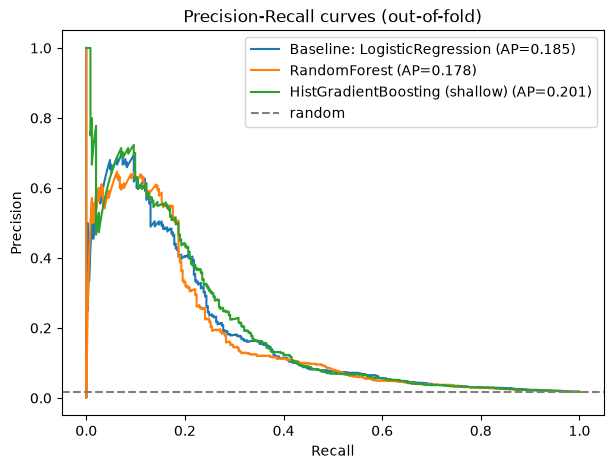

In [9]:
plt.figure(figsize=(7, 5))
for name, p in oof.items():
    pr, rc, _ = precision_recall_curve(y, p)
    plt.plot(rc, pr, label=f'{name} (AP={average_precision_score(y, p):.3f})')
plt.axhline(y.mean(), ls='--', c='grey', label='random')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall curves (out-of-fold)'); plt.legend(); plt.show()

**Model choice: shallow HistGradientBoosting.**
- Highest out-of-fold PR-AUC, roughly 10× the random baseline.
- It captures the non-linear interactions found in EDA (new device × burst, amount × account age) that logistic regression misses.
- It handles missing values natively and is robust to monotonic scaling and outliers.
- Deep, many-tree versions (and LightGBM/XGBoost at default depth) overfit: in our experiments they scored lower in CV. The signal is noisy, so we use depth 3, a low learning rate, large leaves and L2 regularisation.

**Assumptions:**
- Transactions are i.i.d.: no customer ID or timestamp is provided, so we cannot build sequence features or do a time-based split.
- Labels are correct.
- The behavioural fields (`*_last_1h`, `*_last_24h`) are computed *before* the transaction, so there is no leakage.

## 7. Decision threshold & final evaluation

In [10]:
p = oof['HistGradientBoosting (shallow)']
tab = []
for t in [0.03, 0.05, 0.06, 0.08, 0.10, 0.12, 0.15, 0.20]:
    yp = (p >= t).astype(int)
    tab.append({'threshold': t, '% flagged': 100*yp.mean(), 'precision': precision_score(y, yp, zero_division=0),
                'recall': recall_score(y, yp), 'F1': f1_score(y, yp), 'F1.5': fbeta_score(y, yp, beta=1.5)})
pd.DataFrame(tab).round(3)

,threshold,% flagged,precision,recall,F1,F1.5
0,0.03,8.315,0.093,0.436,0.153,0.204
1,0.05,3.805,0.162,0.348,0.221,0.257
2,0.06,2.810,0.201,0.320,0.247,0.271
3,0.08,1.945,0.252,0.278,0.264,0.269
4,0.10,1.400,0.314,0.249,0.278,0.266
5,0.12,1.160,0.358,0.235,0.284,0.263
6,0.15,0.855,0.427,0.207,0.279,0.246
7,0.20,0.655,0.496,0.184,0.269,0.228


The default 0.5 threshold would flag almost nothing. Fraud costs more than a false alarm, but the brief also asks us to *minimise disruption to legitimate customers*. So we tune the threshold to maximise **F-beta with β=1.5**, which weights recall a bit more than precision, and tune it with internal cross-validation (`TunedThresholdClassifierCV`). The threshold is stored inside the model, so `model.predict()` already returns 0/1 labels at the tuned cut-off, and `predict_proba()` is still available for PR-AUC.

In [11]:
final_model = TunedThresholdClassifierCV(
    hgb_model(), scoring=make_scorer(fbeta_score, beta=1.5),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED), random_state=SEED)

# honest estimate of the full procedure (threshold tuning included) with outer CV
outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)
proba_oof = np.zeros(len(y)); pred_oof = np.zeros(len(y), dtype=int)
for tr_idx, va_idx in outer.split(X, y):
    m = TunedThresholdClassifierCV(hgb_model(), scoring=make_scorer(fbeta_score, beta=1.5),
                                   cv=StratifiedKFold(5, shuffle=True, random_state=SEED), random_state=SEED)
    m.fit(X.iloc[tr_idx], y[tr_idx])
    proba_oof[va_idx] = m.predict_proba(X.iloc[va_idx])[:, 1]
    pred_oof[va_idx] = m.predict(X.iloc[va_idx])
print('Nested-CV  PR-AUC = %.4f | F1 = %.4f | Recall = %.4f | Precision = %.4f' % (
      average_precision_score(y, proba_oof), f1_score(y, pred_oof), recall_score(y, pred_oof), precision_score(y, pred_oof)))
print(confusion_matrix(y, pred_oof))

Nested-CV  PR-AUC = 0.2020 | F1 = 0.2500 | Recall = 0.2720 | Precision = 0.2313
[[19328   319]
 [  257    96]]


Tuned decision threshold: 0.0665


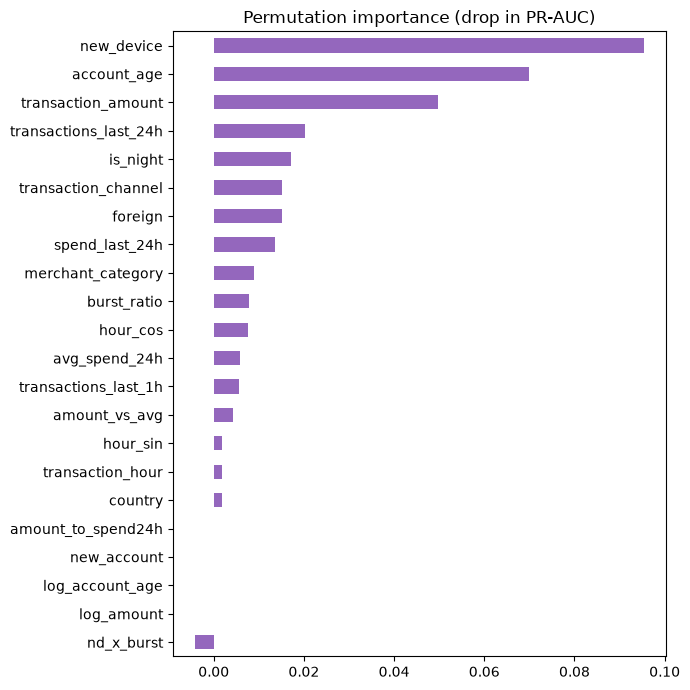

In [12]:
final_model.fit(X, y)
print('Tuned decision threshold: %.4f' % final_model.best_threshold_)
imp = permutation_importance(final_model.estimator_, X, y, scoring='average_precision', n_repeats=5, random_state=SEED, n_jobs=-1)
pd.Series(imp.importances_mean, index=feature_names).sort_values().plot.barh(figsize=(7, 7), color='tab:purple')
plt.title('Permutation importance (drop in PR-AUC)'); plt.tight_layout(); plt.show()

## 8. Save model (model + feature list) as required

In [13]:
joblib.dump((final_model, feature_names), 'model.pkl')
print('model.pkl saved')

model.pkl saved


## 9. Prediction (same procedure as the official upload instructions)

In [14]:
TEAM_NAME = 'The Larpers'

model, features = joblib.load('model.pkl')
input_path = os.environ.get('DATATHON_INPUT_PATH', TEST_PATH)
test_df = pd.read_csv(input_path)
X_test = make_features(test_df)
preds = model.predict(X_test[features])

pd.DataFrame({'prediction': preds}).to_csv(f'{TEAM_NAME}_Datathon 2026_Track 2_Prediction.csv', index=False)
print('Predictions saved successfully!', preds.shape, '| predicted fraud rate: %.3f' % preds.mean())

Predictions saved successfully! (12000,) | predicted fraud rate: 0.042


## 10. requirements.txt (exact versions used)

In [15]:
import importlib.metadata as md
reqs = [f'{p}=={md.version(p)}' for p in ['numpy', 'pandas', 'scikit-learn', 'joblib', 'matplotlib']]
open('requirements.txt', 'w').write('\n'.join(reqs) + '\n')
print(open('requirements.txt').read())

numpy==2.1.3
pandas==2.2.3
scikit-learn==1.6.1
joblib==1.6.0
matplotlib==3.11.2



## Limitations & next steps
- Signal is noisy: PR-AUC ≈ 0.20 (10× random), but precision at useful recall is still modest. A human-review queue is the realistic deployment, not auto-blocking.
- No customer ID or timestamp → no per-customer history or time-ordered validation. With them: per-customer deviation features and a temporal split.
- Distribution shift between train and test → monitor drift and recalibrate the threshold in production.
- Possible improvements: cost-sensitive threshold using real fraud and false-positive costs, probability calibration, and more data or features (device fingerprint, IP, merchant history).